# 06_LSTM_Autoencoder — 비지도 이상탐지

**정상 시계열만으로 학습 → 재구성 오차가 크면 이상**

| Split | Trial | 비고 |
|---|---|---|
| Train (AE 학습) | Test1-43 정상 윈도우만 | 이상 윈도우 제외 |
| Val (threshold 탐색) | Test44 (정상), Test45 (이상) | |
| Test (최종 평가) | Val1,2,5,8,9 | |

In [1]:
from pathlib import Path

BASE_DIR  = Path.home() / 'Desktop' / 'ai1' / 'original_INC_202501'
MODEL_DIR = Path.home() / 'Desktop' / 'ai1' / 'lstmae_model'
MODEL_DIR.mkdir(exist_ok=True)

WINDOW_SIZE = 30          # 3.0s @ 0.1s 간격
STEP_SIZE   = 10          # 1.0s 슬라이딩
FEATURES    = ['Avg Voltage', 'Avg Current']

NORMAL_TEST_IDS   = {1,2,3,4,5,7,8,9,10,11,12,28,29,30,44}
ABNORMAL_TEST_IDS = {6,31,45} | set(range(32,44))
NORMAL_VAL_IDS    = set(range(3,10))
ABNORMAL_VAL_IDS  = {1,2}
VAL_TRIAL_IDS     = {44,45}

ENC_HIDDEN = 32
LATENT     = 16
EPOCHS     = 200
BATCH_SIZE = 32
LR         = 1e-3
PATIENCE   = 20
SEED       = 42

print(f'WINDOW_SIZE={WINDOW_SIZE}  STEP_SIZE={STEP_SIZE}')

WINDOW_SIZE=30  STEP_SIZE=10


In [2]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| Device:', DEVICE)

PyTorch: 2.11.0+cu128 | Device: cuda


In [3]:
# ── 데이터 로드 ───────────────────────────────────────────────────

def parse_folder_id(name):
    m = re.match(r'^(Test|Val)(\d+)_', name, flags=re.IGNORECASE)
    return (m.group(1).capitalize(), int(m.group(2))) if m else (None, None)

def get_label(prefix, idx):
    if prefix == 'Test':
        if idx in NORMAL_TEST_IDS:   return 0
        if idx in ABNORMAL_TEST_IDS: return 1
    elif prefix == 'Val':
        if idx in NORMAL_VAL_IDS:    return 0
        if idx in ABNORMAL_VAL_IDS:  return 1
    raise ValueError()

def get_split(prefix, idx):
    if prefix == 'Val':               return 'test'
    if prefix == 'Test':
        if idx in VAL_TRIAL_IDS:     return 'val'
        return 'train'
    raise ValueError()

def engineer(data_norm):
    V = data_norm[:, 0:1]; I = data_norm[:, 1:2]
    return np.hstack([V, I,
                      np.diff(V, axis=0, prepend=V[[0]]),
                      np.diff(I, axis=0, prepend=I[[0]]),
                      V * I])   # (n, 5)

records = []
for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir(): continue
    prefix, idx = parse_folder_id(d.name)
    if prefix is None: continue
    try: label = get_label(prefix, idx); split = get_split(prefix, idx)
    except: continue
    csvs = list(d.glob('*.csv'))
    if not csvs: continue
    data = pd.read_csv(csvs[0])[FEATURES].astype(float).values
    m, s = data.mean(0), data.std(0); s[s < 1e-8] = 1e-8
    records.append({'folder': d.name, 'label': label, 'split': split,
                    'data': engineer((data - m) / s)})

def make_windows(data, ws, ss):
    return np.stack([data[s:s+ws] for s in range(0, len(data)-ws+1, ss)])

buckets = {'train': ([], []), 'val': ([], []), 'test': ([], [])}
test_folders = []
for r in records:
    w  = make_windows(r['data'], WINDOW_SIZE, STEP_SIZE)
    lb = np.full(len(w), r['label'], dtype=np.float32)
    buckets[r['split']][0].append(w)
    buckets[r['split']][1].append(lb)
    if r['split'] == 'test': test_folders.extend([r['folder']] * len(w))

X = {s: np.vstack(buckets[s][0]).astype(np.float32) for s in buckets}
y = {s: np.concatenate(buckets[s][1])               for s in buckets}
test_folders = np.array(test_folders)

# 글로벌 스케일러 (train 정상 윈도우 기준 fit)
n_feat       = X['train'].shape[2]   # 5
normal_mask  = y['train'] == 0
scaler       = StandardScaler()
scaler.fit(X['train'][normal_mask].reshape(-1, n_feat))

def scale(a):
    n, w, f = a.shape
    return scaler.transform(a.reshape(-1, f)).reshape(n, w, f).astype(np.float32)

Xs = {s: scale(X[s]) for s in X}
Xs_normal = Xs['train'][normal_mask]   # AE 학습 입력 (정상만)

for s in ('train', 'val', 'test'):
    u, c = np.unique(y[s], return_counts=True); cnt = dict(zip(u.astype(int), c))
    print(f'{s:5s}  total={len(y[s]):4d}  normal={cnt.get(0,0):4d}  abnormal={cnt.get(1,0):4d}')
print(f'\nAE 학습 입력 (정상 윈도우): {len(Xs_normal)}개')

train  total= 364  normal= 183  abnormal= 181
val    total=  58  normal=  29  abnormal=  29
test   total= 150  normal=  95  abnormal=  55

AE 학습 입력 (정상 윈도우): 183개


In [4]:
# ── 모델 정의 ─────────────────────────────────────────────────────

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_feat, enc_hidden, latent):
        super().__init__()
        self.encoder    = nn.LSTM(n_feat, enc_hidden, batch_first=True)
        self.enc_to_lat = nn.Linear(enc_hidden, latent)
        self.lat_to_dec = nn.Linear(latent, enc_hidden)
        self.decoder    = nn.LSTM(enc_hidden, n_feat, batch_first=True)

    def forward(self, x):
        _, (h, _) = self.encoder(x)                          # h: (1,B,enc_h)
        latent    = self.enc_to_lat(h[-1])                   # (B, latent)
        dec_in    = self.lat_to_dec(latent).unsqueeze(1)     # (B,1,enc_h)
        dec_in    = dec_in.expand(-1, x.size(1), -1)        # (B,T,enc_h)
        recon, _  = self.decoder(dec_in)                     # (B,T,n_feat)
        return recon


class SeqDataset(Dataset):
    def __init__(self, X):       self.X = torch.from_numpy(X)
    def __len__(self):           return len(self.X)
    def __getitem__(self, i):    return self.X[i]

class LabelDataset(Dataset):
    def __init__(self, X, y):   self.X = torch.from_numpy(X); self.y = torch.from_numpy(y)
    def __len__(self):           return len(self.y)
    def __getitem__(self, i):    return self.X[i], self.y[i]


model = LSTMAutoencoder(n_feat, ENC_HIDDEN, LATENT).to(DEVICE)
mse   = nn.MSELoss()
optim = torch.optim.Adam(model.parameters(), lr=LR)

tr_loader = DataLoader(SeqDataset(Xs_normal),            BATCH_SIZE, shuffle=True)
vl_loader = DataLoader(LabelDataset(Xs['val'],  y['val']),  BATCH_SIZE)
te_loader = DataLoader(LabelDataset(Xs['test'], y['test']), BATCH_SIZE)

print(model)
print(f'\nn_feat={n_feat} | Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

LSTMAutoencoder(
  (encoder): LSTM(5, 32, batch_first=True)
  (enc_to_lat): Linear(in_features=32, out_features=16, bias=True)
  (lat_to_dec): Linear(in_features=16, out_features=32, bias=True)
  (decoder): LSTM(32, 5, batch_first=True)
)

n_feat=5 | Trainable params: 6,844


Ep   1  train=1.0172  val=0.6441
Ep  20  train=0.8441  val=0.4699
Ep  40  train=0.8362  val=0.4634
Ep  60  train=0.8328  val=0.4617
Ep  80  train=0.8292  val=0.4589
Ep 100  train=0.8336  val=0.4623
Early stop ep=113

완료  best_val_recon=0.4577


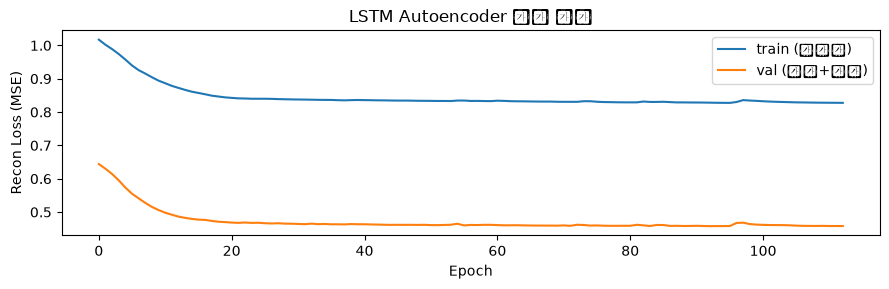

In [5]:
# ── 학습 ──────────────────────────────────────────────────────────

def get_recon_error(loader):
    model.eval()
    errs = []
    with torch.no_grad():
        for batch in loader:
            Xb = batch[0] if isinstance(batch, (list, tuple)) else batch
            Xb = Xb.to(DEVICE)
            e  = ((Xb - model(Xb)) ** 2).mean(dim=(1, 2))   # (B,)
            errs.append(e.cpu().numpy())
    return np.concatenate(errs)


best_vl = float('inf'); pc = 0
model_path = str(MODEL_DIR / 'best_ae.pt')
hist = {'train': [], 'val': []}

for ep in range(1, EPOCHS + 1):
    model.train(); tl = 0; tn = 0
    for Xb in tr_loader:
        Xb = Xb.to(DEVICE); optim.zero_grad()
        loss = mse(model(Xb), Xb)
        loss.backward(); optim.step()
        tl += loss.item() * len(Xb); tn += len(Xb)
    tl /= tn
    vl  = get_recon_error(vl_loader).mean()
    hist['train'].append(tl); hist['val'].append(vl)

    if ep % 20 == 0 or ep == 1:
        print(f'Ep {ep:3d}  train={tl:.4f}  val={vl:.4f}')

    if vl < best_vl:
        best_vl = vl; pc = 0; torch.save(model.state_dict(), model_path)
    else:
        pc += 1
        if pc >= PATIENCE: print(f'Early stop ep={ep}'); break

model.load_state_dict(torch.load(model_path, map_location=DEVICE))
print(f'\n완료  best_val_recon={best_vl:.4f}')

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(hist['train'], label='train (정상만)'); ax.plot(hist['val'], label='val (정상+이상)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Recon Loss (MSE)')
ax.set_title('LSTM Autoencoder 학습 곡선'); ax.legend()
plt.tight_layout(); plt.savefig(str(MODEL_DIR / 'train_curve.png'), dpi=150); plt.show()

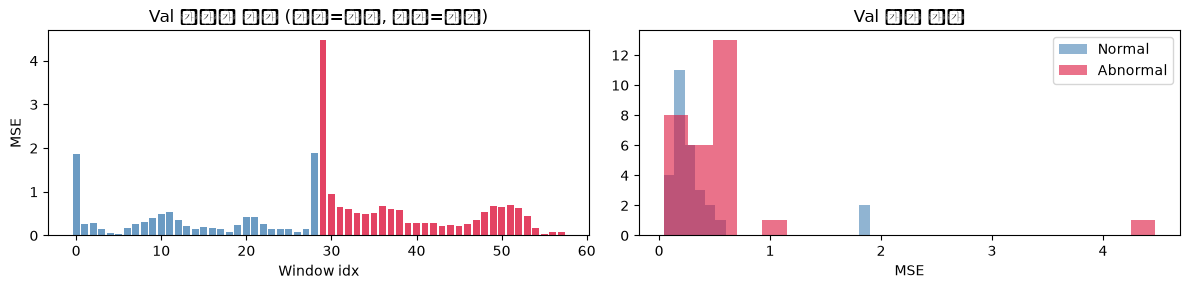

Val 정상  오차: mean=0.3483  std=0.4360
Val 이상  오차: mean=0.5670  std=0.7703

최적 Threshold: 0.1664  (val F1=0.732)


In [6]:
# ── Val 재구성 오차 시각화 + Threshold 탐색 ───────────────────────

val_err  = get_recon_error(vl_loader)
val_true = y['val'].astype(int)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

colors = ['steelblue' if l == 0 else 'crimson' for l in val_true]
axes[0].bar(range(len(val_err)), val_err, color=colors, alpha=0.8)
axes[0].set_title('Val 재구성 오차 (파랑=정상, 빨강=이상)')
axes[0].set_xlabel('Window idx'); axes[0].set_ylabel('MSE')

# 오차 분포 비교
axes[1].hist(val_err[val_true == 0], bins=20, alpha=0.6, label='Normal', color='steelblue')
axes[1].hist(val_err[val_true == 1], bins=20, alpha=0.6, label='Abnormal', color='crimson')
axes[1].set_title('Val 오차 분포'); axes[1].set_xlabel('MSE'); axes[1].legend()

plt.tight_layout(); plt.savefig(str(MODEL_DIR / 'val_error_dist.png'), dpi=150); plt.show()

print(f'Val 정상  오차: mean={val_err[val_true==0].mean():.4f}  std={val_err[val_true==0].std():.4f}')
print(f'Val 이상  오차: mean={val_err[val_true==1].mean():.4f}  std={val_err[val_true==1].std():.4f}')

# F1 최적 threshold
best_t, best_f1 = 0.0, 0.0
for t in np.percentile(val_err, np.arange(5, 95, 2)):
    p  = (val_err >= t).astype(int)
    f1 = f1_score(val_true, p, zero_division=0)
    if f1 > best_f1: best_f1 = f1; best_t = t

print(f'\n최적 Threshold: {best_t:.4f}  (val F1={best_f1:.3f})')

In [7]:
# ── Test 평가 ─────────────────────────────────────────────────────

test_err  = get_recon_error(te_loader)
test_true = y['test'].astype(int)
test_pred = (test_err >= best_t).astype(int)

auc = roc_auc_score(test_true, test_err)

print('=== Window-level ===')
print(classification_report(test_true, test_pred,
                             target_names=['Normal(0)', 'Abnormal(1)'],
                             zero_division=0))
print(f'ROC-AUC: {auc:.4f}')

# Trial-level
print(f'\n=== Trial-level ===')
print(f'{"Trial":45s}  {"True":5s}  {"Win":4s}  {"MeanError":10s}  {"Threshold":10s}  판정')
print('-' * 85)
trial_results = []
for folder in sorted(set(test_folders)):
    mask   = test_folders == folder
    err_m  = test_err[mask].mean()
    true_l = int(test_true[mask][0])
    pred_l = 1 if err_m >= best_t else 0
    ok     = 'O' if pred_l == true_l else 'X'
    trial_results.append({'folder': folder, 'true': true_l, 'pred': pred_l})
    print(f'{folder:45s}  {true_l:5d}  {mask.sum():4d}  {err_m:10.4f}  {best_t:10.4f}  {ok}')

df  = pd.DataFrame(trial_results)
acc = (df['true'] == df['pred']).mean()
print(f'\nTrial Accuracy: {acc:.3f}  ({int(acc*len(df))}/{len(df)})')

=== Window-level ===
              precision    recall  f1-score   support

   Normal(0)       0.67      0.92      0.78        95
 Abnormal(1)       0.62      0.24      0.34        55

    accuracy                           0.67       150
   macro avg       0.65      0.58      0.56       150
weighted avg       0.65      0.67      0.62       150

ROC-AUC: 0.7998

=== Trial-level ===
Trial                                          True   Win   MeanError   Threshold   판정
-------------------------------------------------------------------------------------
Val1_130A_22TS_170WFR                              1    24      0.9250      0.1664  O
Val2_130A_24TS_200WFR                              1    31      0.2827      0.1664  O
Val5_217A_22TS_170WFR                              0    33      1.5843      0.1664  X
Val8_237A_22TS_200WFR                              0    32      0.0889      0.1664  O
Val9_237A_24TS_170WFR                              0    30      0.1711      0.1664  X

Trial Accur

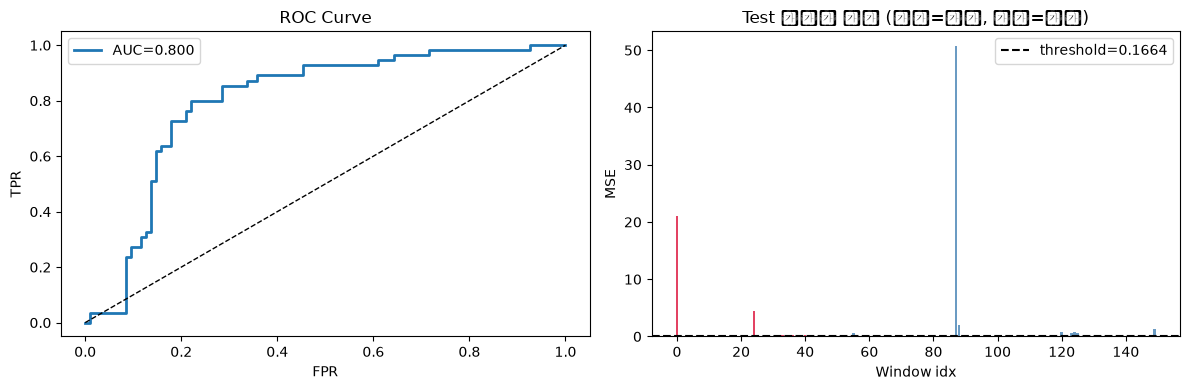

In [8]:
# ── ROC 곡선 + Test 오차 시각화 ───────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC
fpr, tpr, _ = roc_curve(test_true, test_err)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC={auc:.3f}')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend()

# Test 윈도우 재구성 오차
colors = ['steelblue' if l == 0 else 'crimson' for l in test_true]
axes[1].bar(range(len(test_err)), test_err, color=colors, alpha=0.8)
axes[1].axhline(best_t, color='black', linestyle='--', lw=1.5, label=f'threshold={best_t:.4f}')
axes[1].set_title('Test 재구성 오차 (파랑=정상, 빨강=이상)')
axes[1].set_xlabel('Window idx'); axes[1].set_ylabel('MSE'); axes[1].legend()

plt.tight_layout(); plt.savefig(str(MODEL_DIR / 'test_eval.png'), dpi=150); plt.show()